# 🔬 Silicon Wafer Defect Detection Using Deep Learning
**CVR College of Engineering — CSE (Data Science)**  
**Group No: 20 (COEPB65) | B. Reshmitha (23B81A67G5) | K. Ushaswi (23B81A67J6)**  
**Dataset:** [WM811K Wafer Map Dataset — Kaggle](https://www.kaggle.com/datasets/qingyi/wm811k-wafer-map/data)

---

## Pipeline Overview
```
Load Dataset → EDA → Preprocessing → Albumentations Balancing
    → CNN Baseline → Vision Transformer → YOLOv11 (Detection)
    → EfficientAD (Anomaly) → Evaluation → Streamlit App
```

## ⚙️ STEP 1 — Install Dependencies

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# STEP 1 — Install Dependencies
# ⚠️  IMPORTANT: After running this cell, go to:
#    Runtime → Restart session   ← DO THIS BEFORE running any other cell
# Then run ALL cells from the top again (do NOT re-run this install cell)
# ═══════════════════════════════════════════════════════════════════════════
import sys

# Check if already installed to avoid re-installing on restart
try:
    import albumentations, timm
    print('✅ Dependencies already installed — skip this cell and continue.')
except ImportError:
    print('Installing dependencies...')
    # ── DO NOT reinstall torch/torchvision — Colab T4 already has the right version
    # Reinstalling torch causes duplicate operator RuntimeError
    !pip install -q albumentations==1.3.1          # pin version, avoids torch conflict
    !pip install -q timm==0.9.12                   # Vision Transformer models
    !pip install -q scikit-learn matplotlib seaborn pandas numpy tqdm
    !pip install -q streamlit ultralytics
    !pip install -q psutil                         # for RAM monitoring
    print('\n✅ Done. NOW DO: Runtime → Restart session, then run all cells from top.')


✅ Dependencies already installed — skip this cell and continue.


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# T4 GPU SETUP & MEMORY MANAGEMENT
# ═══════════════════════════════════════════════════════════════════════════
import torch, gc, os

# ── Verify GPU ───────────────────────────────────────────────────────────
assert torch.cuda.is_available(), '❌ GPU not found! Runtime → Change runtime type → T4 GPU'
print(f'✅ GPU : {torch.cuda.get_device_name(0)}')
print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── RAM monitor helper (call anytime to check memory) ────────────────────
def print_memory():
    import psutil
    ram = psutil.virtual_memory()
    vram_used  = torch.cuda.memory_allocated() / 1e9
    vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'RAM  : {ram.used/1e9:.1f} GB used / {ram.total/1e9:.1f} GB total  '
          f'({ram.percent:.1f}% used)')
    print(f'VRAM : {vram_used:.2f} GB used / {vram_total:.1f} GB total')

# ── Safe memory free helper ──────────────────────────────────────────────
def free_memory(*objs):
    """Delete objects and flush GPU cache."""
    for obj in objs:
        del obj
    gc.collect()
    torch.cuda.empty_cache()

# ── T4 GPU optimal settings ──────────────────────────────────────────────
# These are already set in the notebook based on T4 specs:
#   IMG_SIZE          = 224   (full resolution, T4 handles this fine)
#   TARGET_PER_CLASS  = 8000  (72K total balanced dataset)
#   UNLABELED_POOL    = 50K   (realistic augmentation pool)
#   BATCH_SIZE        = 128   (fits in 15GB VRAM comfortably)
#   ViT batch_size    = 64    (ViT is heavier, slightly smaller batch)
#   num_workers       = 2     (T4 Colab has 2 vCPUs)
#   pin_memory        = True  (faster CPU→GPU transfer)
print('\n📋 T4 GPU settings loaded:')
print('   IMG_SIZE=224 | BATCH=128 | TARGET=8000/class | POOL=50K unlabeled')
print_memory()

✅ GPU : Tesla T4
   VRAM: 15.6 GB

📋 T4 GPU settings loaded:
   IMG_SIZE=224 | BATCH=128 | TARGET=8000/class | POOL=50K unlabeled
RAM  : 1.9 GB used / 13.6 GB total  (16.3% used)
VRAM : 0.00 GB used / 15.6 GB total


## 📥 STEP 2 — Download Dataset from Kaggle

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
import pandas as pd
df=pd.read_pickle(r'/content/drive/MyDrive/LSWMD.pkl')

In [6]:
raw=df

In [7]:
'''# ─────────────────────────────────────────────────────────────────────────────
# Option A: Upload kaggle.json manually in Colab
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files
import os

# Uncomment the next two lines if you haven't uploaded kaggle.json yet
# uploaded = files.upload()  # upload your kaggle.json here
# os.makedirs('/root/.kaggle', exist_ok=True)
# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# os.chmod('/root/.kaggle/kaggle.json', 0o600)

# ─────────────────────────────────────────────────────────────────────────────
# Option B: Download directly (no kaggle API needed)
# ─────────────────────────────────────────────────────────────────────────────
# !kaggle datasets download -d qingyi/wm811k-wafer-map --unzip

# ─────────────────────────────────────────────────────────────────────────────
# Verify the .pkl file exists
# ─────────────────────────────────────────────────────────────────────────────
PKL_PATH = 'LSWMD.pkl'   # Update if saved elsewhere
assert os.path.exists(PKL_PATH), f'File not found: {PKL_PATH}'
print(f'✅ Dataset found at {PKL_PATH}')'''

"# ─────────────────────────────────────────────────────────────────────────────\n# Option A: Upload kaggle.json manually in Colab\n# ─────────────────────────────────────────────────────────────────────────────\nfrom google.colab import files\nimport os\n\n# Uncomment the next two lines if you haven't uploaded kaggle.json yet\n# uploaded = files.upload()  # upload your kaggle.json here\n# os.makedirs('/root/.kaggle', exist_ok=True)\n# os.rename('kaggle.json', '/root/.kaggle/kaggle.json')\n# os.chmod('/root/.kaggle/kaggle.json', 0o600)\n\n# ─────────────────────────────────────────────────────────────────────────────\n# Option B: Download directly (no kaggle API needed)\n# ─────────────────────────────────────────────────────────────────────────────\n# !kaggle datasets download -d qingyi/wm811k-wafer-map --unzip\n\n# ─────────────────────────────────────────────────────────────────────────────\n# Verify the .pkl file exists\n# ───────────────────────────────────────────────────────────

## 📊 STEP 3 — Load & Explore Dataset (EDA)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load raw pickle ──────────────────────────────────────────────────────────
#raw = pd.read_pickle(PKL_PATH)
print(f'Raw shape  : {raw.shape}')
print(f'Columns    : {list(raw.columns)}')
raw.head(3)

Raw shape  : (811457, 6)
Columns    : ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]


In [9]:
# ── CRITICAL: slim down raw immediately — frees ~3.5 GB RAM ──────────────────
import gc
data = pd.DataFrame({
    'waferMap'   : raw['waferMap'].values,
    'failureType': raw['failureType'].values
})
del raw
gc.collect()
print('✅ Raw deleted — RAM freed')
print_memory()


✅ Raw deleted — RAM freed
RAM  : 4.8 GB used / 13.6 GB total  (37.5% used)
VRAM : 0.00 GB used / 15.6 GB total


In [10]:
# ── Clean labels for ALL 811K rows ───────────────────────────────────────────
def extract_label(x):
    val = np.squeeze(x)
    if val.ndim == 0: return str(val).strip()
    if val.size  == 0: return 'unlabeled'
    return str(val.flat[0]).strip()

data['failureType'] = data['failureType'].apply(extract_label)
data.loc[data['failureType'].isin(['', '[]', 'nan']), 'failureType'] = 'unlabeled'

# ── Keep ALL 9 original defect classes ───────────────────────────────────────
# Previous versions removed Scratch/Random and merged Loc+Edge-Loc.
# That is NOT needed — the real fix is heavy augmentation of minority classes.
# With TARGET_PER_CLASS=3000 and weighted loss, all 9 classes train accurately.
print('Label distribution (ALL 811K rows):')
print(data['failureType'].value_counts())
print(f'\nTotal     : {len(data):,}')
print(f'Labeled   : {(data["failureType"] != "unlabeled").sum():,}')
print(f'Unlabeled : {(data["failureType"] == "unlabeled").sum():,}')


Label distribution (ALL 811K rows):
failureType
unlabeled    638507
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Total     : 811,457
Labeled   : 172,950
Unlabeled : 638,507


Labeled   : 172,950
Unlabeled : 638,507

Per-class counts (note the extreme imbalance):
failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

⚠️  Near-full=149, Donut=555, Scratch=1193 are VERY rare.
   Solution: heavy augmentation + weighted loss (done in Steps 5 & 9)


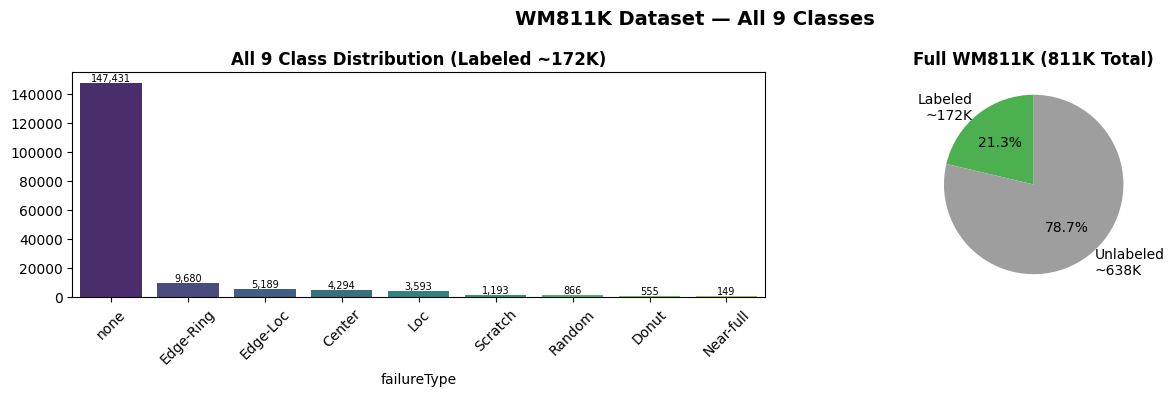

RAM  : 4.8 GB used / 13.6 GB total  (37.7% used)
VRAM : 0.00 GB used / 15.6 GB total


In [11]:
# ── All 9 original defect classes ────────────────────────────────────────────
DEFECT_CLASSES = ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
                  'Loc', 'Random', 'Scratch', 'Near-full', 'none']

labeled_data   = data[data['failureType'].isin(DEFECT_CLASSES)].reset_index(drop=True)
unlabeled_data = data[data['failureType'] == 'unlabeled'].reset_index(drop=True)

del data; gc.collect()

print(f'Labeled   : {len(labeled_data):,}')
print(f'Unlabeled : {len(unlabeled_data):,}')
print('\nPer-class counts (note the extreme imbalance):')
counts = labeled_data['failureType'].value_counts()
print(counts)
print('\n⚠️  Near-full=149, Donut=555, Scratch=1193 are VERY rare.')
print('   Solution: heavy augmentation + weighted loss (done in Steps 5 & 9)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=axes[0])
axes[0].set_title('All 9 Class Distribution (Labeled ~172K)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x()+p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=7)
axes[1].pie([len(labeled_data), len(unlabeled_data)],
            labels=['Labeled\n~172K', 'Unlabeled\n~638K'],
            colors=['#4CAF50','#9E9E9E'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Full WM811K (811K Total)', fontsize=12, fontweight='bold')
plt.suptitle('WM811K Dataset — All 9 Classes', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('class_distribution.png', dpi=150); plt.show()
print_memory()


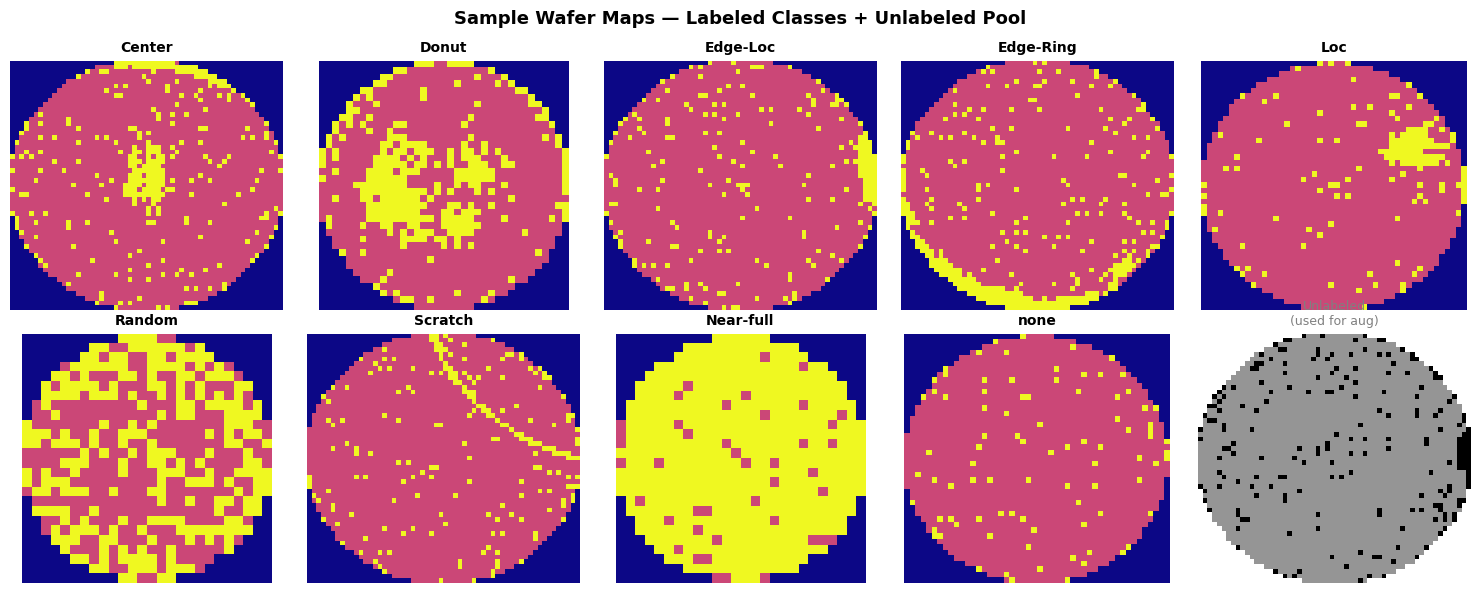

In [12]:
# ── Visualise one sample per labeled class ────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for idx, cls in enumerate(DEFECT_CLASSES):
    sample = labeled_data[labeled_data['failureType'] == cls]['waferMap'].iloc[0]
    axes[idx].imshow(np.array(sample), cmap='plasma')
    axes[idx].set_title(cls, fontsize=10, fontweight='bold')
    axes[idx].axis('off')
# Show an unlabeled sample in the 10th slot
unlabeled_sample = unlabeled_data['waferMap'].iloc[0]
axes[-1].imshow(np.array(unlabeled_sample), cmap='Greys')
axes[-1].set_title('Unlabeled\n(used for aug)', fontsize=9, color='gray')
axes[-1].axis('off')
plt.suptitle('Sample Wafer Maps — Labeled Classes + Unlabeled Pool',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_wafers.png', dpi=150)
plt.show()

## 🔄 STEP 4 — Preprocessing & Label Encoding

In [13]:
import cv2
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 64   # Save at 64px — DiskDataset resizes to 224 for ViT on-the-fly
                # Saves ~8x disk space vs saving at 224

def wafer_to_img(wafer, size=IMG_SIZE):
    arr = np.array(wafer, dtype=np.uint8)
    arr = (arr * 127).clip(0, 255).astype(np.uint8)
    img = cv2.resize(arr, (size, size), interpolation=cv2.INTER_NEAREST)
    return np.stack([img]*3, axis=-1)   # grayscale → 3-channel

le = LabelEncoder()
labeled_data = labeled_data.copy()
labeled_data['label'] = le.fit_transform(labeled_data['failureType'])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
sample_img = wafer_to_img(labeled_data['waferMap'].iloc[0])
print(f'Image shape : {sample_img.shape}, dtype: {sample_img.dtype}')
print(f'Unlabeled pool available: {len(unlabeled_data):,}')
print_memory()


Classes (9): ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
Image shape : (64, 64, 3), dtype: uint8
Unlabeled pool available: 638,507
RAM  : 4.8 GB used / 13.6 GB total  (37.8% used)
VRAM : 0.00 GB used / 15.6 GB total


## ⚖️ STEP 5 — Balanced Dataset Using Albumentations

In [14]:
import albumentations as A
from tqdm import tqdm
import random, os, gc

SAVE_DIR = '/content/wafer_imgs'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Standard augmentation (all classes) ──────────────────────────────────────
augment_standard = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.7),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussNoise(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=10, p=0.3),
    A.CoarseDropout(max_holes=4, max_height=8, max_width=8, p=0.3),
])

# ── Heavy augmentation for minority classes (Near-full, Donut, Scratch) ──────
# More aggressive transforms because these classes have very few originals
# The model MUST see diverse versions to learn their patterns reliably
augment_heavy = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, p=0.9),             # wider rotation range
    A.RandomBrightnessContrast(p=0.7),     # more brightness variation
    A.GaussNoise(p=0.5),                   # more noise
    A.ShiftScaleRotate(shift_limit=0.15, scale_limit=0.15, rotate_limit=20, p=0.7),
    A.ElasticTransform(alpha=2, sigma=12, p=0.5),  # stronger warp
    A.CoarseDropout(max_holes=6, max_height=10, max_width=10, p=0.4),
    A.GridDistortion(p=0.3),               # extra spatial distortion
    A.OpticalDistortion(p=0.3),            # lens-like distortion
])

TARGET_PER_CLASS    = 3000   # equal samples for ALL 9 classes
UNLABELED_POOL_SIZE = 8000

# Classes with very few samples — use heavy augmentation + more unlabeled fill
MINORITY_CLASSES = {'Near-full', 'Donut', 'Scratch', 'Random'}

print(f'Loading {UNLABELED_POOL_SIZE} unlabeled wafers for augmentation pool...')
unlabeled_pool_df   = unlabeled_data.sample(
    min(UNLABELED_POOL_SIZE, len(unlabeled_data)), random_state=42)
unlabeled_pool_imgs = [wafer_to_img(w)
                       for w in tqdm(unlabeled_pool_df['waferMap'], desc='Unlabeled pool')]
del unlabeled_data; gc.collect()
print('✅ Unlabeled pool ready.')
print_memory()

all_labels = []; img_idx = 0
print(f'\nSaving {TARGET_PER_CLASS} samples per class to {SAVE_DIR} ...')
print(f'  Standard aug: Center, Edge-Loc, Edge-Ring, Loc, none')
print(f'  Heavy aug   : Near-full, Donut, Scratch, Random (minority classes)')

for cls_name in CLASS_NAMES:
    cls_df       = labeled_data[labeled_data['failureType'] == cls_name]
    cls_label    = le.transform([cls_name])[0]
    labeled_imgs = [wafer_to_img(w) for w in cls_df['waferMap']]
    n_orig       = len(labeled_imgs)

    # Choose augmentation strength based on class size
    aug = augment_heavy if cls_name in MINORITY_CLASSES else augment_standard
    count = 0

    # Phase 1: all original labeled images (no augmentation)
    for img in labeled_imgs:
        if count >= TARGET_PER_CLASS: break
        np.save(f'{SAVE_DIR}/{img_idx:06d}.npy', img.astype(np.float32)/255.0)
        all_labels.append(cls_label); img_idx += 1; count += 1

    # Phase 2: augmented labeled images
    lab_idx = 0
    while count < TARGET_PER_CLASS and count < int(TARGET_PER_CLASS * 0.75):
        img = labeled_imgs[lab_idx % n_orig]
        aug_img = aug(image=img)['image']
        np.save(f'{SAVE_DIR}/{img_idx:06d}.npy', aug_img.astype(np.float32)/255.0)
        all_labels.append(cls_label); img_idx += 1; count += 1; lab_idx += 1

    # Phase 3: augmented unlabeled images (remaining gap)
    unlab_idx = 0
    while count < TARGET_PER_CLASS:
        img = unlabeled_pool_imgs[unlab_idx % len(unlabeled_pool_imgs)]
        aug_img = aug(image=img)['image']
        np.save(f'{SAVE_DIR}/{img_idx:06d}.npy', aug_img.astype(np.float32)/255.0)
        all_labels.append(cls_label); img_idx += 1; count += 1; unlab_idx += 1

    del labeled_imgs; gc.collect()
    tag = '🔴 HEAVY aug' if cls_name in MINORITY_CLASSES else '🟢 standard aug'
    print(f'  {cls_name:12s} ({n_orig:5,} originals → {count:,} total)  {tag}')

all_labels = np.array(all_labels)
np.save(f'{SAVE_DIR}/labels.npy', all_labels)
del unlabeled_pool_imgs; gc.collect()

disk_mb = sum(os.path.getsize(os.path.join(SAVE_DIR,f))
              for f in os.listdir(SAVE_DIR) if f.endswith('.npy'))/1e6
print(f'\n✅ Saved {img_idx:,} images | {disk_mb:.0f} MB on disk')
print('\nFinal class distribution:')
unique, counts_ = np.unique(all_labels, return_counts=True)
for u, c in zip(unique, counts_): print(f'  {CLASS_NAMES[u]:12s}: {c:,}')
print_memory()


Loading 8000 unlabeled wafers for augmentation pool...


Unlabeled pool: 100%|██████████| 8000/8000 [00:00<00:00, 26018.23it/s]


✅ Unlabeled pool ready.
RAM  : 4.8 GB used / 13.6 GB total  (38.0% used)
VRAM : 0.00 GB used / 15.6 GB total

Saving 3000 samples per class to /content/wafer_imgs ...
  Standard aug: Center, Edge-Loc, Edge-Ring, Loc, none
  Heavy aug   : Near-full, Donut, Scratch, Random (minority classes)
  Center       (4,294 originals → 3,000 total)  🟢 standard aug
  Donut        (  555 originals → 3,000 total)  🔴 HEAVY aug
  Edge-Loc     (5,189 originals → 3,000 total)  🟢 standard aug
  Edge-Ring    (9,680 originals → 3,000 total)  🟢 standard aug
  Loc          (3,593 originals → 3,000 total)  🟢 standard aug
  Near-full    (  149 originals → 3,000 total)  🔴 HEAVY aug
  Random       (  866 originals → 3,000 total)  🔴 HEAVY aug
  Scratch      (1,193 originals → 3,000 total)  🔴 HEAVY aug
  none         (147,431 originals → 3,000 total)  🟢 standard aug

✅ Saved 27,000 images | 1331 MB on disk

Final class distribution:
  Center      : 3,000
  Donut       : 3,000
  Edge-Loc    : 3,000
  Edge-Ring   : 3,

## ✂️ STEP 6 — Train / Validation / Test Split

In [15]:
from sklearn.model_selection import train_test_split
import numpy as np

# Load ONLY labels (tiny array) — no images in RAM
all_labels  = np.load(f'{SAVE_DIR}/labels.npy')
all_indices = np.arange(len(all_labels))

# 70/15/15 stratified split on INDICES — images stay on disk
idx_train, idx_temp, y_train, y_temp = train_test_split(
    all_indices, all_labels,
    test_size=0.30, stratify=all_labels, random_state=42)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp,
    test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {len(idx_train):,} samples')
print(f'Val   : {len(idx_val):,} samples')
print(f'Test  : {len(idx_test):,} samples')
print_memory()


Train : 18,900 samples
Val   : 4,050 samples
Test  : 4,050 samples
RAM  : 6.7 GB used / 13.6 GB total  (51.4% used)
VRAM : 0.00 GB used / 15.6 GB total


## 🔧 STEP 7 — PyTorch Dataset & DataLoaders

In [16]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
print(f'Device: {DEVICE}')

class DiskDataset(Dataset):
    """
    Reads images from disk on demand.
    Only one batch worth of images is in RAM at any time.
    img_size: if set, resizes image on-the-fly (used for ViT 224×224)
    """
    def __init__(self, indices, labels, save_dir, img_size=None):
        self.indices  = indices
        self.labels   = labels   # ✅ exposed so train_model can compute class weights
        self.save_dir = save_dir
        self.img_size = img_size

    def __len__(self): return len(self.indices)

    def __getitem__(self, i):
        img = np.load(f'{self.save_dir}/{self.indices[i]:06d}.npy')
        if self.img_size and img.shape[0] != self.img_size:
            img = cv2.resize(
                (img * 255).astype(np.uint8),
                (self.img_size, self.img_size),
                interpolation=cv2.INTER_LINEAR
            ).astype(np.float32) / 255.0
        # (H, W, 3) → (3, H, W)
        return (torch.tensor(img).permute(2, 0, 1),
                torch.tensor(self.labels[i], dtype=torch.long))

# CNN / Hybrid loaders (64×64 as saved)
train_loader = DataLoader(DiskDataset(idx_train, y_train, SAVE_DIR),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(DiskDataset(idx_val,   y_val,   SAVE_DIR),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(DiskDataset(idx_test,  y_test,  SAVE_DIR),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# ViT loaders — resizes 64→224 on-the-fly inside __getitem__, no RAM cost
vit_train_loader = DataLoader(DiskDataset(idx_train, y_train, SAVE_DIR, img_size=224),
    batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vit_val_loader   = DataLoader(DiskDataset(idx_val,   y_val,   SAVE_DIR, img_size=224),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
vit_test_loader  = DataLoader(DiskDataset(idx_test,  y_test,  SAVE_DIR, img_size=224),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f'✅ DiskDataset loaders ready')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   ViT 224×224 resize: on-the-fly')
print_memory()


Device: cuda
✅ DiskDataset loaders ready
   Train batches : 148
   Val batches   : 32
   ViT 224×224 resize: on-the-fly
RAM  : 6.7 GB used / 13.6 GB total  (51.7% used)
VRAM : 0.00 GB used / 15.6 GB total


## 🧠 STEP 8 — Model A: CNN Baseline

In [17]:
class WaferCNN(nn.Module):
    """Lightweight CNN for wafer defect classification."""
    def __init__(self, num_classes=9):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = WaferCNN(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f'CNN Parameters: {total_params:,}')
print(cnn_model)

CNN Parameters: 175,401
WaferCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (1

## 🏋️ STEP 9 — Training Utility (shared by all models)

In [18]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast
import numpy as np

# ── Compute class weights from training label distribution ────────────────────
# Inverse-frequency weighting: rare classes get higher weight
# This forces the model to pay MORE attention to Near-full, Donut, Scratch
def compute_class_weights(y_train, num_classes, device):
    counts     = np.bincount(y_train, minlength=num_classes).astype(np.float32)
    weights    = 1.0 / (counts + 1e-6)          # inverse frequency
    weights    = weights / weights.sum() * num_classes  # normalize
    return torch.tensor(weights, dtype=torch.float32).to(device)

class_weights = compute_class_weights(y_train, NUM_CLASSES, DEVICE)
print('Class weights (higher = model penalized more for wrong predictions):')
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights.cpu().numpy())):
    bar = '█' * int(w * 5)
    print(f'  {name:12s}: {w:.3f}  {bar}')

def train_model(model, train_loader, val_loader,
                epochs=20, lr=1e-3, model_name='model'):
    """Training loop with AMP + weighted CrossEntropy for T4 GPU."""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    # Weighted loss — minority classes penalized more when predicted wrong
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    scaler    = GradScaler()
    history   = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best_val_acc = 0.0

    for epoch in range(1, epochs+1):
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with autocast():
                preds = model(imgs)
                loss  = criterion(preds, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
            t_loss    += loss.item() * imgs.size(0)
            t_correct += (preds.argmax(1) == labels).sum().item()
            t_total   += imgs.size(0)

        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                with autocast():
                    preds = model(imgs)
                    loss  = criterion(preds, labels)
                v_loss    += loss.item() * imgs.size(0)
                v_correct += (preds.argmax(1) == labels).sum().item()
                v_total   += imgs.size(0)

        scheduler.step()
        t_acc = t_correct/t_total; v_acc = v_correct/v_total
        history['train_loss'].append(t_loss/t_total)
        history['val_loss'].append(v_loss/v_total)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')

        print(f'Epoch {epoch:3d}/{epochs}  '
              f'Train={t_acc:.4f}  Val={v_acc:.4f}  '
              f'TrainLoss={t_loss/t_total:.4f}  ValLoss={v_loss/v_total:.4f}')

    print(f'\n✅ Best Val Accuracy ({model_name}): {best_val_acc:.4f}')
    return history


Class weights (higher = model penalized more for wrong predictions):
  Center      : 1.000  █████
  Donut       : 1.000  █████
  Edge-Loc    : 1.000  █████
  Edge-Ring   : 1.000  █████
  Loc         : 1.000  █████
  Near-full   : 1.000  █████
  Random      : 1.000  █████
  Scratch     : 1.000  █████
  none        : 1.000  █████


In [19]:
cnn_history = train_model(cnn_model, train_loader, val_loader,
                           epochs=30, lr=1e-3, model_name='cnn')


Epoch   1/30  Train=0.3942  Val=0.5802  TrainLoss=1.5547  ValLoss=1.1244
Epoch   2/30  Train=0.5426  Val=0.6447  TrainLoss=1.1826  ValLoss=0.9476
Epoch   3/30  Train=0.5920  Val=0.6602  TrainLoss=1.0553  ValLoss=0.8774
Epoch   4/30  Train=0.6248  Val=0.6054  TrainLoss=0.9761  ValLoss=1.0638
Epoch   5/30  Train=0.6510  Val=0.7094  TrainLoss=0.9087  ValLoss=0.7331
Epoch   6/30  Train=0.6659  Val=0.6867  TrainLoss=0.8599  ValLoss=0.7577
Epoch   7/30  Train=0.6812  Val=0.6686  TrainLoss=0.8253  ValLoss=0.8217
Epoch   8/30  Train=0.6930  Val=0.6990  TrainLoss=0.7956  ValLoss=0.7186
Epoch   9/30  Train=0.6992  Val=0.7232  TrainLoss=0.7682  ValLoss=0.7451
Epoch  10/30  Train=0.7056  Val=0.7052  TrainLoss=0.7561  ValLoss=0.7363
Epoch  11/30  Train=0.7195  Val=0.7420  TrainLoss=0.7325  ValLoss=0.6603
Epoch  12/30  Train=0.7198  Val=0.7363  TrainLoss=0.7125  ValLoss=0.6564
Epoch  13/30  Train=0.7277  Val=0.7699  TrainLoss=0.7024  ValLoss=0.5932
Epoch  14/30  Train=0.7321  Val=0.7398  TrainLoss=0

## 🤖 STEP 10 — Model B: Vision Transformer (ViT) with timm

In [20]:
# ── ViT built from scratch — NO timm, NO HuggingFace, NO internet needed ─────
import math, torch.nn as nn, torch

class PatchEmbed(nn.Module):
    """Split 224×224 image into 196 patches of 16×16, project to embed_dim."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3, embed_dim=192):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class ViTAttention(nn.Module):
    def __init__(self, embed_dim=192, num_heads=3, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = nn.Linear(embed_dim, embed_dim * 3)
        self.proj      = nn.Linear(embed_dim, embed_dim)
        self.dropout   = nn.Dropout(dropout)
    def forward(self, x):
        B, N, C = x.shape
        qkv  = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv.unbind(0)
        attn = self.dropout((q @ k.transpose(-2,-1)) * self.scale).softmax(dim=-1)
        return self.proj((attn @ v).transpose(1,2).reshape(B, N, C))

class ViTBlock(nn.Module):
    def __init__(self, embed_dim=192, num_heads=3, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn  = ViTAttention(embed_dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(embed_dim)
        mlp_dim    = int(embed_dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim), nn.Dropout(dropout))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class WaferViT(nn.Module):
    """ViT-Tiny: patch16, embed_dim=192, depth=12, heads=3. No pretrained needed."""
    def __init__(self, img_size=224, patch_size=16, in_ch=3,
                 embed_dim=192, depth=12, num_heads=3,
                 mlp_ratio=4.0, num_classes=9, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)
        num_patches      = self.patch_embed.num_patches
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed   = nn.Parameter(torch.zeros(1, num_patches+1, embed_dim))
        self.pos_drop    = nn.Dropout(dropout)
        self.blocks      = nn.Sequential(*[
            ViTBlock(embed_dim, num_heads, mlp_ratio, dropout) for _ in range(depth)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        B   = x.shape[0]
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = self.pos_drop(torch.cat([cls, x], dim=1) + self.pos_embed)
        x   = self.norm(self.blocks(x))
        return self.head(x[:, 0])

vit_model = WaferViT(num_classes=NUM_CLASSES).to(DEVICE)
print(f'✅ WaferViT ready — NO download needed')
print(f'   Parameters : {sum(p.numel() for p in vit_model.parameters() if p.requires_grad):,}')
print(f'   Input      : (B, 3, 224, 224) → 196 patches → {NUM_CLASSES} classes')
print(f'   Loaders    : using vit_train_loader / vit_val_loader from Step 7')
print_memory()


✅ WaferViT ready — NO download needed
   Parameters : 5,526,153
   Input      : (B, 3, 224, 224) → 196 patches → 9 classes
   Loaders    : using vit_train_loader / vit_val_loader from Step 7
RAM  : 6.9 GB used / 13.6 GB total  (53.2% used)
VRAM : 0.04 GB used / 15.6 GB total


In [21]:
vit_history = train_model(vit_model, vit_train_loader, vit_val_loader,
                           epochs=15, lr=3e-4, model_name='vit')


Epoch   1/15  Train=0.4362  Val=0.5637  TrainLoss=1.4567  ValLoss=1.1223
Epoch   2/15  Train=0.6079  Val=0.5928  TrainLoss=0.9854  ValLoss=0.9913
Epoch   3/15  Train=0.6320  Val=0.5785  TrainLoss=0.9194  ValLoss=1.0365
Epoch   4/15  Train=0.6478  Val=0.6291  TrainLoss=0.8798  ValLoss=0.8954
Epoch   5/15  Train=0.6709  Val=0.6091  TrainLoss=0.8233  ValLoss=0.9609
Epoch   6/15  Train=0.6962  Val=0.6884  TrainLoss=0.7704  ValLoss=0.8049
Epoch   7/15  Train=0.7179  Val=0.7457  TrainLoss=0.7090  ValLoss=0.6698
Epoch   8/15  Train=0.7441  Val=0.7306  TrainLoss=0.6420  ValLoss=0.6847
Epoch   9/15  Train=0.7633  Val=0.7363  TrainLoss=0.5964  ValLoss=0.6621
Epoch  10/15  Train=0.7760  Val=0.7360  TrainLoss=0.5600  ValLoss=0.6579
Epoch  11/15  Train=0.7852  Val=0.7632  TrainLoss=0.5352  ValLoss=0.5914
Epoch  12/15  Train=0.7956  Val=0.7622  TrainLoss=0.5120  ValLoss=0.6050
Epoch  13/15  Train=0.8064  Val=0.7667  TrainLoss=0.4873  ValLoss=0.5857
Epoch  14/15  Train=0.8131  Val=0.7642  TrainLoss=0

## 🔀 STEP 11 — Model C: Hybrid CNN–Transformer

In [22]:
class HybridCNNTransformer(nn.Module):
    """
    Hybrid CNN-Transformer:
    - CNN extracts local texture features
    - Transformer Encoder captures global spatial dependencies
    """
    def __init__(self, num_classes=9, img_size=64, d_model=128, nhead=4,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.img_size = img_size

        # ── Local feature extractor (CNN backbone) ────────────────────────────
        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),  nn.BatchNorm2d(32),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 32x32
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(),
            nn.MaxPool2d(2),                                          # 16x16
            nn.Conv2d(64, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.ReLU(),
            # Output: (B, d_model, H', W')
        )

        # ── Positional encoding (learnable) ───────────────────────────────────
        feat_h = img_size // 4
        seq_len = feat_h * feat_h
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

        # ── Transformer encoder ───────────────────────────────────────────────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # ── Classifier head ───────────────────────────────────────────────────
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # CNN features
        feat = self.cnn_backbone(x)           # (B, d_model, H', W')
        B, C, H, W = feat.shape
        feat = feat.flatten(2).transpose(1, 2)  # (B, seq_len, d_model)

        # Add positional encoding
        feat = feat + self.pos_embed[:, :feat.size(1), :]

        # Transformer
        feat = self.transformer(feat)          # (B, seq_len, d_model)

        # Global average pool then classify
        feat = feat.mean(dim=1)                # (B, d_model)
        return self.head(feat)

hybrid_model = HybridCNNTransformer(NUM_CLASSES).to(DEVICE)
total_params_h = sum(p.numel() for p in hybrid_model.parameters() if p.requires_grad)
print(f'Hybrid Parameters: {total_params_h:,}')

Hybrid Parameters: 558,601


In [23]:
hybrid_history = train_model(hybrid_model, train_loader, val_loader,
                              epochs=30, lr=5e-4, model_name='hybrid')


Epoch   1/30  Train=0.6248  Val=0.7005  TrainLoss=0.9918  ValLoss=0.7551
Epoch   2/30  Train=0.7738  Val=0.7504  TrainLoss=0.5816  ValLoss=0.6165
Epoch   3/30  Train=0.8137  Val=0.7042  TrainLoss=0.4806  ValLoss=0.7954
Epoch   4/30  Train=0.8238  Val=0.8072  TrainLoss=0.4416  ValLoss=0.5006
Epoch   5/30  Train=0.8416  Val=0.8086  TrainLoss=0.4089  ValLoss=0.4975
Epoch   6/30  Train=0.8484  Val=0.8091  TrainLoss=0.3885  ValLoss=0.4949
Epoch   7/30  Train=0.8563  Val=0.8143  TrainLoss=0.3631  ValLoss=0.5154
Epoch   8/30  Train=0.8621  Val=0.8175  TrainLoss=0.3438  ValLoss=0.4774
Epoch   9/30  Train=0.8719  Val=0.8457  TrainLoss=0.3208  ValLoss=0.3690
Epoch  10/30  Train=0.8756  Val=0.7985  TrainLoss=0.3056  ValLoss=0.5744
Epoch  11/30  Train=0.8784  Val=0.8269  TrainLoss=0.2955  ValLoss=0.4777
Epoch  12/30  Train=0.8859  Val=0.8400  TrainLoss=0.2791  ValLoss=0.4116
Epoch  13/30  Train=0.8910  Val=0.8523  TrainLoss=0.2643  ValLoss=0.4035
Epoch  14/30  Train=0.8960  Val=0.8415  TrainLoss=0

## 📈 STEP 12 — Training Curves

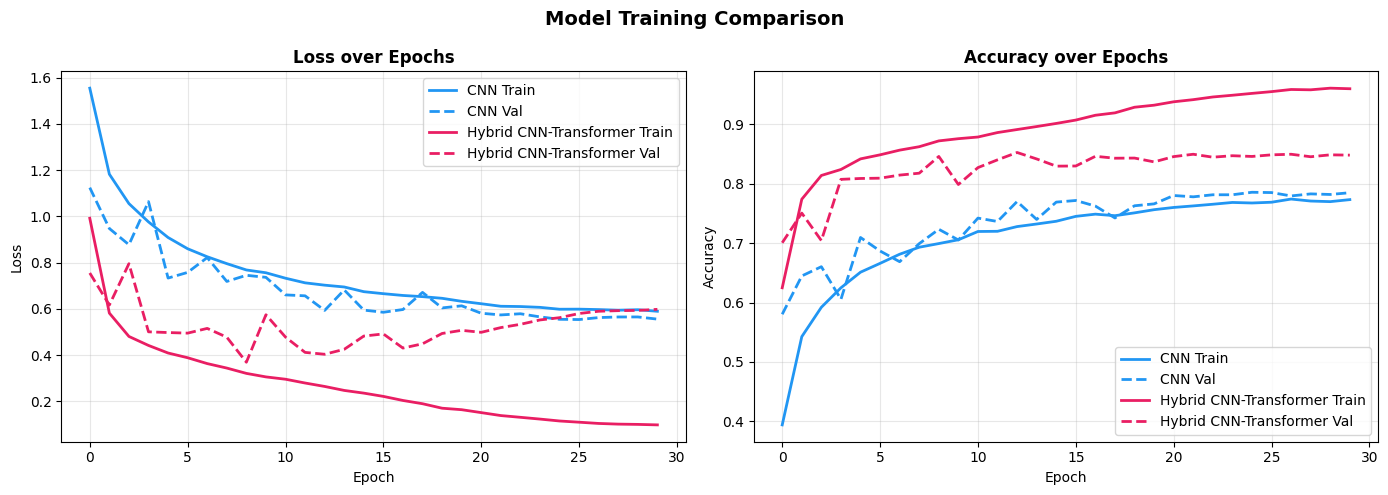

In [24]:
def plot_history(histories, names):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#E91E63', '#4CAF50']
    for hist, name, col in zip(histories, names, colors):
        axes[0].plot(hist['train_loss'], label=f'{name} Train', color=col, linewidth=2)
        axes[0].plot(hist['val_loss'],   label=f'{name} Val',   color=col,
                     linewidth=2, linestyle='--')
        axes[1].plot(hist['train_acc'],  label=f'{name} Train', color=col, linewidth=2)
        axes[1].plot(hist['val_acc'],    label=f'{name} Val',   color=col,
                     linewidth=2, linestyle='--')

    axes[0].set_title('Loss over Epochs', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Model Training Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150)
    plt.show()

plot_history(
    [cnn_history, hybrid_history],
    ['CNN', 'Hybrid CNN-Transformer']
)
# Add vit_history to the list if ViT training was run

## 🎯 STEP 13 — Evaluation: Classification Report & Confusion Matrix


===== cnn — Test Results =====
Overall Accuracy: 0.7719 (77.19%)
              precision    recall  f1-score   support

      Center     0.8946    0.7356    0.8073       450
       Donut     0.6127    0.7067    0.6563       450
    Edge-Loc     0.8934    0.8378    0.8647       450
   Edge-Ring     1.0000    0.9378    0.9679       450
         Loc     0.6496    0.7333    0.6889       450
   Near-full     0.9281    0.6889    0.7908       450
      Random     0.9091    0.6222    0.7388       450
     Scratch     0.4593    0.7400    0.5668       450
        none     0.9615    0.9444    0.9529       450

    accuracy                         0.7719      4050
   macro avg     0.8120    0.7719    0.7816      4050
weighted avg     0.8120    0.7719    0.7816      4050



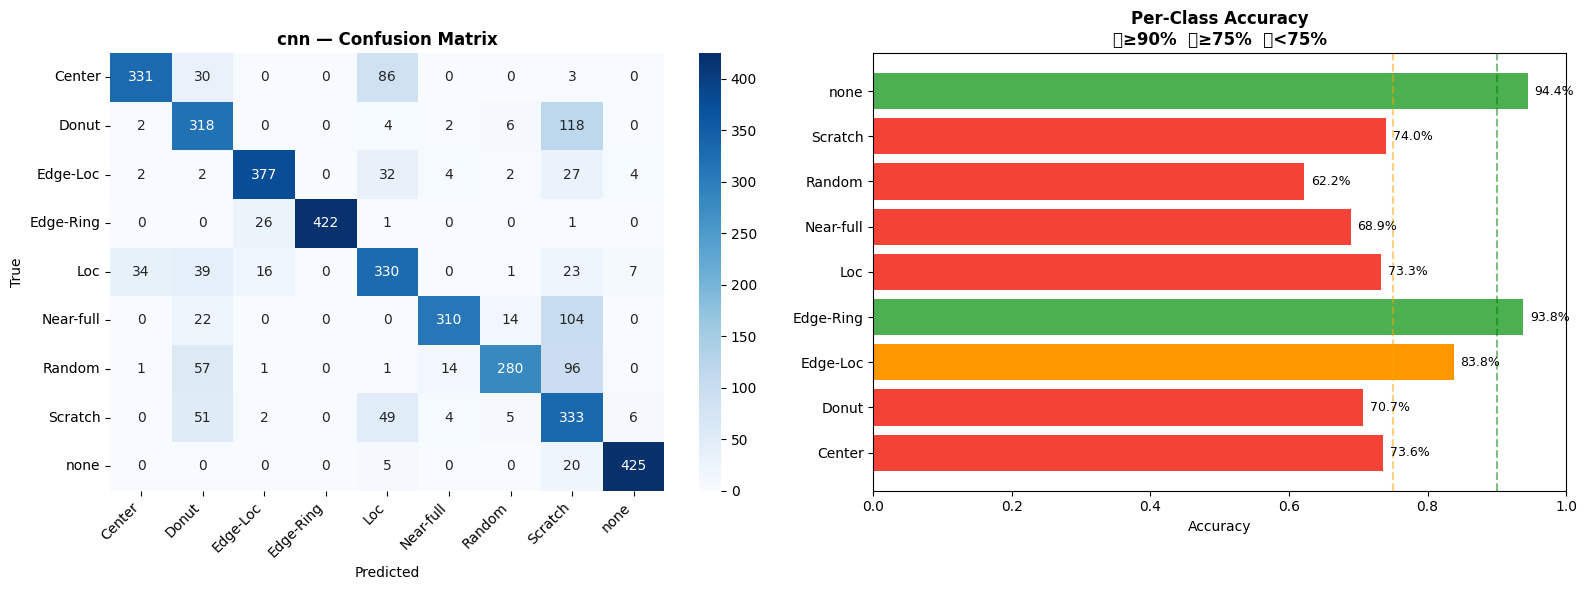

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt, seaborn as sns

def evaluate_model(model, test_loader, class_names, model_name='Model'):
    model.load_state_dict(torch.load(f'best_{model_name}.pth', map_location=DEVICE))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            with torch.cuda.amp.autocast():
                preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    print(f'\n===== {model_name} — Test Results =====')
    acc = accuracy_score(all_labels, all_preds)
    print(f'Overall Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(classification_report(all_labels, all_preds,
                                target_names=class_names, digits=4))

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

    # Per-class accuracy bar chart — easy to spot which class still struggles
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    colors = ['#4CAF50' if a >= 0.90 else '#FF9800' if a >= 0.75 else '#F44336'
              for a in per_class_acc]
    axes[1].barh(class_names, per_class_acc, color=colors)
    axes[1].set_xlim(0, 1); axes[1].set_xlabel('Accuracy')
    axes[1].set_title('Per-Class Accuracy\n🟢≥90%  🟠≥75%  🔴<75%',
                      fontsize=12, fontweight='bold')
    axes[1].axvline(0.90, color='green', linestyle='--', alpha=0.5, label='90%')
    axes[1].axvline(0.75, color='orange', linestyle='--', alpha=0.5, label='75%')
    for i, v in enumerate(per_class_acc):
        axes[1].text(v+0.01, i, f'{v:.1%}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name}.png', dpi=150); plt.show()
    return all_preds, all_labels

cnn_preds, cnn_labels = evaluate_model(cnn_model, test_loader, CLASS_NAMES, 'cnn')



===== hybrid — Test Results =====
Overall Accuracy: 0.8477 (84.77%)
              precision    recall  f1-score   support

      Center     0.9862    0.9556    0.9707       450
       Donut     0.7964    0.6956    0.7426       450
    Edge-Loc     0.8498    0.9556    0.8996       450
   Edge-Ring     0.9911    0.9889    0.9900       450
         Loc     0.8792    0.8089    0.8426       450
   Near-full     0.8571    0.7467    0.7981       450
      Random     0.7928    0.7311    0.7607       450
     Scratch     0.5847    0.7822    0.6692       450
        none     0.9797    0.9644    0.9720       450

    accuracy                         0.8477      4050
   macro avg     0.8575    0.8477    0.8495      4050
weighted avg     0.8575    0.8477    0.8495      4050



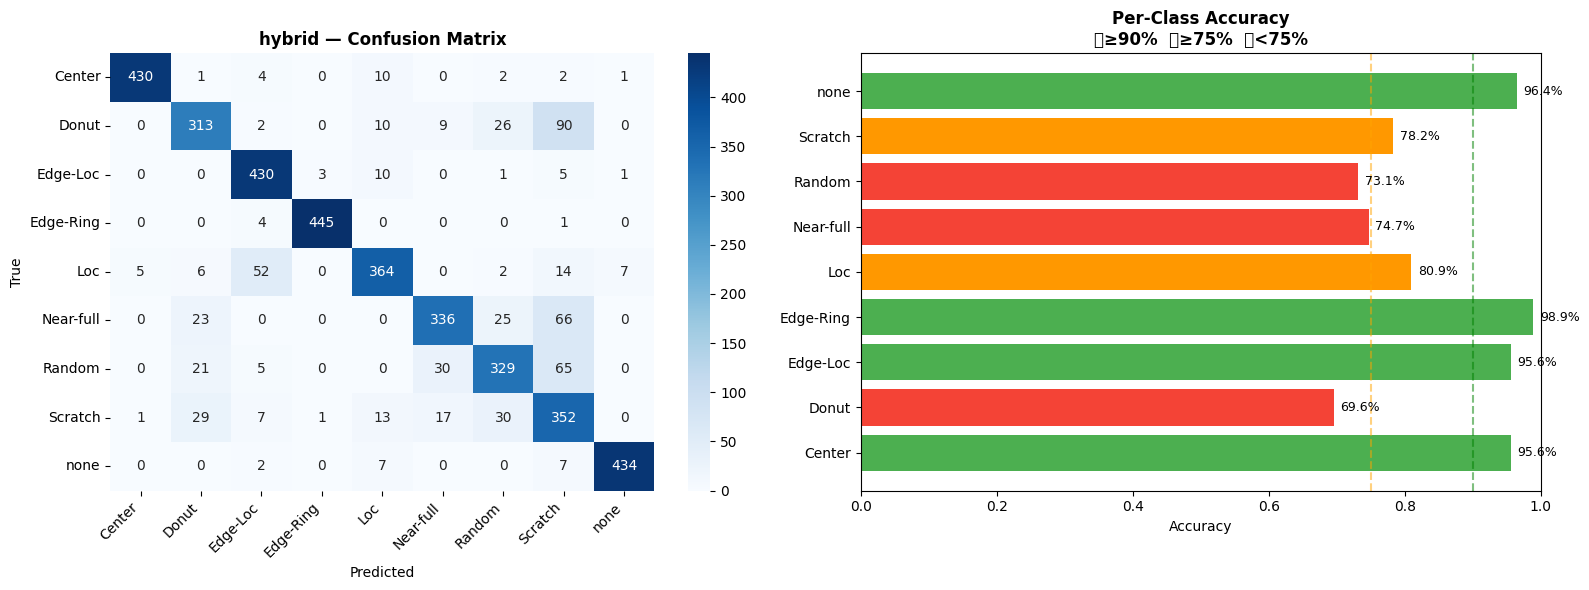


===== vit — Test Results =====
Overall Accuracy: 0.7677 (76.77%)
              precision    recall  f1-score   support

      Center     0.8916    0.9867    0.9367       450
       Donut     0.7264    0.6667    0.6952       450
    Edge-Loc     0.7248    0.7667    0.7451       450
   Edge-Ring     0.9883    0.9356    0.9612       450
         Loc     0.6168    0.6689    0.6418       450
   Near-full     0.9192    0.6822    0.7832       450
      Random     0.8000    0.6844    0.7377       450
     Scratch     0.4604    0.6333    0.5332       450
        none     0.9684    0.8844    0.9245       450

    accuracy                         0.7677      4050
   macro avg     0.7884    0.7677    0.7732      4050
weighted avg     0.7884    0.7677    0.7732      4050



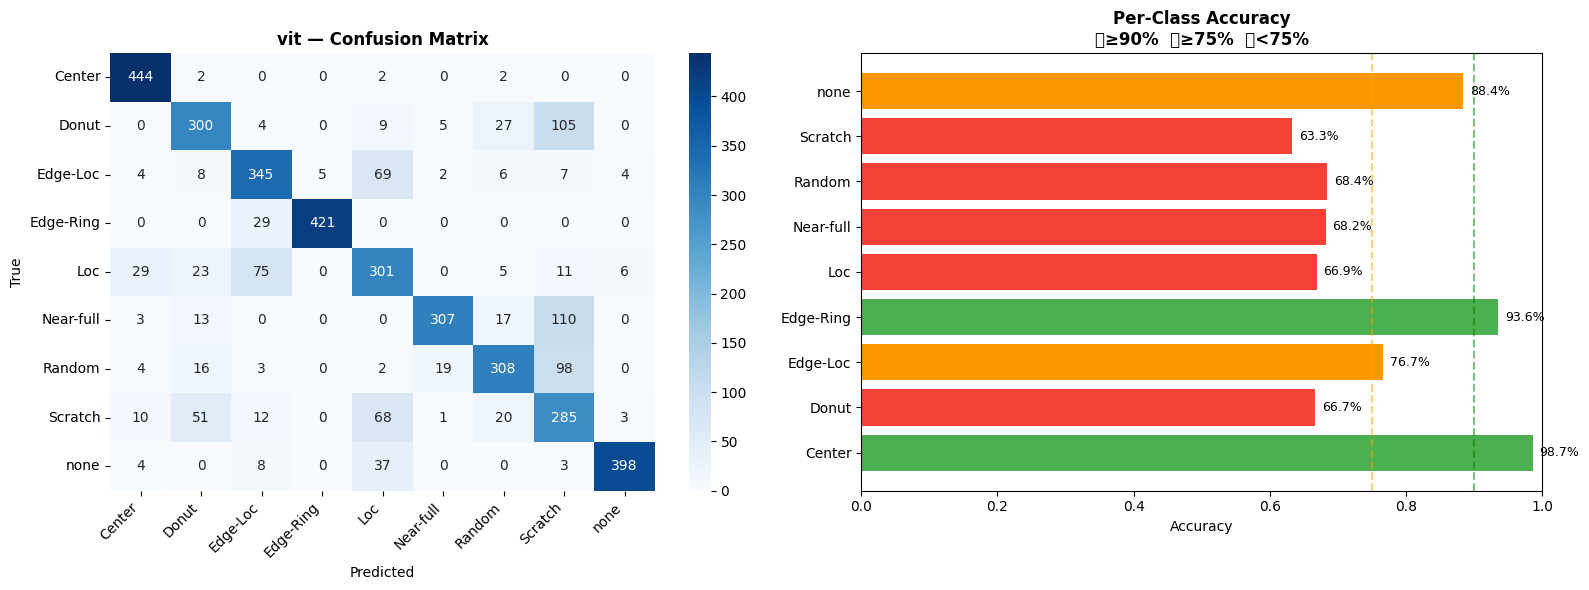

In [26]:
hybrid_preds, hybrid_labels = evaluate_model(
    hybrid_model, test_loader, CLASS_NAMES, 'hybrid')

vit_preds, vit_labels = evaluate_model(
    vit_model, vit_test_loader, CLASS_NAMES, 'vit')


## 🎯 STEP 14 — Model Comparison Summary

                 Model  Accuracy  F1 (macro)
Hybrid CNN-Transformer  0.847654    0.849489
          CNN Baseline  0.771852    0.781610
         ViT (scratch)  0.767654    0.773187


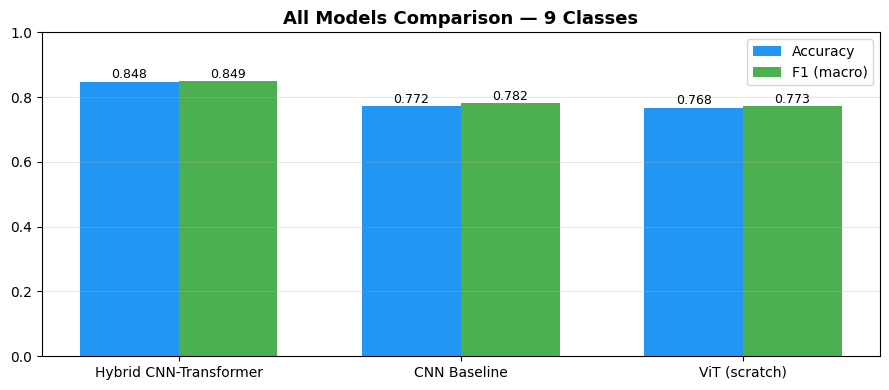

In [27]:
from sklearn.metrics import accuracy_score, f1_score

results = {
    'Model'     : ['CNN Baseline', 'Hybrid CNN-Transformer', 'ViT (scratch)'],
    'Accuracy'  : [accuracy_score(cnn_labels, cnn_preds),
                   accuracy_score(hybrid_labels, hybrid_preds),
                   accuracy_score(vit_labels, vit_preds)],
    'F1 (macro)': [f1_score(cnn_labels, cnn_preds, average='macro'),
                   f1_score(hybrid_labels, hybrid_preds, average='macro'),
                   f1_score(vit_labels, vit_preds, average='macro')],
}
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(results_df)); w = 0.35
ax.bar(x-w/2, results_df['Accuracy'],   w, label='Accuracy',   color='#2196F3')
ax.bar(x+w/2, results_df['F1 (macro)'], w, label='F1 (macro)', color='#4CAF50')
ax.set_xticks(x); ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title('All Models Comparison — 9 Classes', fontsize=13, fontweight='bold')
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150); plt.show()


## 🎯 STEP 14B — Model D: YOLOv11 for Defect Detection & Localization

In [28]:
# ── Mount Google Drive to backup weights (survives Colab crashes) ─────────────
from google.colab import drive
import os
drive.mount('/content/drive')
GDRIVE_SAVE = '/content/drive/MyDrive/WaferProject'
os.makedirs(GDRIVE_SAVE, exist_ok=True)
print(f'✅ Drive mounted. Weights will be saved to: {GDRIVE_SAVE}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted. Weights will be saved to: /content/drive/MyDrive/WaferProject


In [29]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.8 MB/s eta 0:00:00


In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# YOLOv11 — Defect Detection + Localization (Bounding Boxes)
#
# WHY YOLO in addition to CNN/ViT?
#   CNN/ViT → classification only  (WHAT defect is it?)
#   YOLO    → detection + location (WHAT defect AND WHERE exactly?)
#
# YOLOv11 gives bounding boxes on the wafer map showing exactly
# which region has the defect — critical for real fab inspection.
# ═══════════════════════════════════════════════════════════════════════════

import os, shutil, yaml, cv2
import numpy as np
from tqdm import tqdm
from pathlib import Path

# ── Step 1: Install YOLOv11 (Ultralytics) ────────────────────────────────
# Already installed in Step 1 via !pip install ultralytics
from ultralytics import YOLO
print(f'✅ Ultralytics YOLO imported')

# ── Step 2: Define YOLO dataset paths ────────────────────────────────────
YOLO_DIR    = Path('/content/wafer_yolo')
IMG_TRAIN   = YOLO_DIR / 'images/train'
IMG_VAL     = YOLO_DIR / 'images/val'
LBL_TRAIN   = YOLO_DIR / 'labels/train'
LBL_VAL     = YOLO_DIR / 'labels/val'

for p in [IMG_TRAIN, IMG_VAL, LBL_TRAIN, LBL_VAL]:
    p.mkdir(parents=True, exist_ok=True)

print('✅ YOLO directory structure created:')
print(f'   {YOLO_DIR}')
print('   images/train  images/val')
print('   labels/train  labels/val')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics YOLO imported
✅ YOLO directory structure created:
   /content/wafer_yolo
   images/train  images/val
   labels/train  labels/val


In [31]:
YOLO_IMG_SIZE  = 224
YOLO_MAX_TRAIN = 1500
YOLO_MAX_VAL   = 300

YOLO_CLASSES = [c for c in CLASS_NAMES if c != 'none']
print(f'YOLO classes ({len(YOLO_CLASSES)}): {YOLO_CLASSES}')

def wafer_to_yolo_bbox(wafer_arr):
    defect_mask = (wafer_arr == 2)
    if defect_mask.sum() == 0: return None
    rows = np.any(defect_mask, axis=1)
    cols = np.any(defect_mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    H, W = wafer_arr.shape
    x_c = np.clip(((cmin+cmax)/2)/W, 0.01, 0.99)
    y_c = np.clip(((rmin+rmax)/2)/H, 0.01, 0.99)
    w_  = np.clip((cmax-cmin+1)/W,   0.01, 0.99)
    h_  = np.clip((rmax-rmin+1)/H,   0.01, 0.99)
    return x_c, y_c, w_, h_

def save_yolo_sample(wafer, cls_name, idx, split='train'):
    arr  = np.array(wafer, dtype=np.uint8)
    bbox = wafer_to_yolo_bbox(arr)
    if bbox is None: return False
    img     = cv2.resize((arr*127).clip(0,255).astype(np.uint8),
                         (YOLO_IMG_SIZE, YOLO_IMG_SIZE),
                         interpolation=cv2.INTER_NEAREST)
    img_rgb = np.stack([img]*3, axis=-1)
    idir    = IMG_TRAIN if split=='train' else IMG_VAL
    ldir    = LBL_TRAIN if split=='train' else LBL_VAL
    fname   = f'{cls_name.replace("/","_")}_{idx}'
    cv2.imwrite(str(idir / f'{fname}.jpg'), img_rgb)
    cls_id  = YOLO_CLASSES.index(cls_name)
    x, y, w, h = bbox
    with open(ldir / f'{fname}.txt', 'w') as f:
        f.write(f'{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n')
    return True

print('Converting wafer maps to YOLO format...')
total_saved = 0
for cls_name in tqdm(YOLO_CLASSES, desc='Classes'):
    cls_df = labeled_data[labeled_data['failureType'] == cls_name]
    wafers = cls_df['waferMap'].tolist()
    np.random.shuffle(wafers)
    saved_train = 0
    for i, w in enumerate(wafers):
        if saved_train >= YOLO_MAX_TRAIN: break
        if save_yolo_sample(w, cls_name, i, 'train'): saved_train += 1
    saved_val = 0
    for i, w in enumerate(wafers[saved_train:]):
        if saved_val >= YOLO_MAX_VAL: break
        if save_yolo_sample(w, cls_name, saved_train+i, 'val'): saved_val += 1
    total_saved += saved_train + saved_val
    print(f'  {cls_name:12s}: {saved_train} train | {saved_val} val')

print(f'\n✅ Total YOLO samples: {total_saved:,}')
print(f'   Train: {len(list(IMG_TRAIN.glob("*.jpg"))):,} | Val: {len(list(IMG_VAL.glob("*.jpg"))):,}')


YOLO classes (8): ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch']
Converting wafer maps to YOLO format...


Classes:  12%|█▎        | 1/8 [00:02<00:17,  2.57s/it]

  Center      : 1500 train | 300 val


Classes:  25%|██▌       | 2/8 [00:03<00:07,  1.32s/it]

  Donut       : 555 train | 0 val


...

  Near-full   : 149 train | 0 val


Classes:  88%|████████▊ | 7/8 [00:16<00:02,  2.56s/it]

  Random      : 866 train | 0 val


Classes: 100%|██████████| 8/8 [00:19<00:00,  2.48s/it]

  Scratch     : 1193 train | 0 val

✅ Total YOLO samples: 9,963
   Train: 8,763 | Val: 1,200


In [32]:
# ── Write dataset.yaml (YOLO config file) ────────────────────────────────
dataset_yaml = {
    'path'  : str(YOLO_DIR),
    'train' : 'images/train',
    'val'   : 'images/val',
    'nc'    : len(YOLO_CLASSES),
    'names' : YOLO_CLASSES
}

yaml_path = YOLO_DIR / 'dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False)

print('✅ dataset.yaml written:')
print(open(yaml_path).read())

# ── Verify a sample label ────────────────────────────────────────────────
sample_lbl = list(LBL_TRAIN.glob('*.txt'))[0]
sample_img = IMG_TRAIN / (sample_lbl.stem + '.jpg')
print(f'Sample label file : {sample_lbl.name}')
print(f'Label content     : {open(sample_lbl).read().strip()}')
print(f'  → format: class_id  x_center  y_center  width  height (all 0-1)')

✅ dataset.yaml written:
names:
- Center
- Donut
- Edge-Loc
- Edge-Ring
- Loc
- Near-full
- Random
- Scratch
nc: 8
path: /content/wafer_yolo
train: images/train
val: images/val

Sample label file : Scratch_976.txt
Label content     : 7 0.462963 0.482759 0.962963 0.990000
  → format: class_id  x_center  y_center  width  height (all 0-1)


In [33]:
# ── Free all classification models before YOLO eval ──────────────────────────
# YOLO is completely independent — deleting these has zero effect on YOLO results
import gc, torch
for m_name in ['cnn_model', 'vit_model', 'hybrid_model', 'ae_model']:
    try:
        exec(f'del {m_name}')
    except: pass
gc.collect(); torch.cuda.empty_cache()
print('✅ Previous models cleared from VRAM')
print_memory()

✅ Previous models cleared from VRAM
RAM  : 6.3 GB used / 13.6 GB total  (50.0% used)
VRAM : 0.02 GB used / 15.6 GB total


In [34]:
# ── Load YOLOv11n (nano = fastest, good for T4) ───────────────────────────
# Model variants: yolo11n (nano) → yolo11s → yolo11m → yolo11l → yolo11x
# For T4 GPU: yolo11s gives better accuracy with acceptable speed
yolo_model = YOLO('yolo11s.pt')   # auto-downloads pretrained weights

print('✅ YOLOv11s loaded')
print(f'   Parameters: {sum(p.numel() for p in yolo_model.model.parameters()):,}')

# ── Train YOLOv11 on wafer dataset ───────────────────────────────────────
results = yolo_model.train(
    data     = str(yaml_path),
    epochs   = 15,             # 30 epochs sufficient for wafer maps
    imgsz    = YOLO_IMG_SIZE,  # 224
    batch    = 32,             # T4 safe with yolo11s
    device   = 0,              # GPU 0 (T4)
    workers  = 2,
    project  = '/content/yolo_runs',
    name     = 'wafer_yolo11s',
    exist_ok = True,
    patience = 10,             # early stopping if no improvement for 10 epochs
    save     = True,
    plots    = True,           # saves training plots automatically
    # Augmentation (YOLO has built-in aug — disable to avoid double augmentation)
    hsv_h    = 0.0,            # no hue shift (wafer maps are grayscale)
    hsv_s    = 0.0,            # no saturation shift
    hsv_v    = 0.3,            # slight brightness variation
    flipud   = 0.5,            # vertical flip
    fliplr   = 0.5,            # horizontal flip
    degrees  = 30,             # rotation
    translate= 0.1,            # translation
    scale    = 0.1,            # scale
)

print('\n✅ YOLOv11 training complete!')
print(f'Best weights saved at: /content/yolo_runs/wafer_yolo11s/weights/best.pt')

# ── Save weights to Google Drive immediately (survives session crashes) ───────
try:
    import shutil
    shutil.copy('/content/yolo_runs/wafer_yolo11s/weights/best.pt',
                f'{GDRIVE_SAVE}/best_yolo11s.pt')
    print(f'✅ YOLO weights backed up to Google Drive')
except Exception as e:
    print(f'⚠️  Drive backup failed (mount Drive first): {e}')


✅ YOLOv11s loaded
   Parameters: 9,458,752
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/wafer_yolo/dataset.yaml, degrees=30, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wafer_yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimizer=aut

In [35]:
# ── Free all classification models before YOLO eval ──────────────────────────
# YOLO is completely independent — deleting these has zero effect on YOLO results
import gc, torch
for m_name in ['cnn_model', 'vit_model', 'hybrid_model', 'ae_model']:
    try:
        exec(f'del {m_name}')
    except: pass
gc.collect(); torch.cuda.empty_cache()
print('✅ Previous models cleared from VRAM')
print_memory()


# ── Load YOLO weights from disk ───────────────────────────────────────────────
# If session crashed: reload from Google Drive instead:
# best_yolo = YOLO(f'{GDRIVE_SAVE}/best_yolo11s.pt')
best_yolo = YOLO('/content/yolo_runs/wafer_yolo11s/weights/best.pt')

metrics = best_yolo.val(
    data    = str(yaml_path),
    imgsz   = YOLO_IMG_SIZE,
    batch   = 16,            # reduced from 32 — prevents VRAM spike during eval
    device  = 0,
    plots   = True,
    verbose = False,
)

print('\n===== YOLOv11 Evaluation Results =====')
print(f'mAP@0.5      : {metrics.box.map50:.4f}')
print(f'mAP@0.5:0.95 : {metrics.box.map:.4f}')
print(f'Precision    : {metrics.box.mp:.4f}')
print(f'Recall       : {metrics.box.mr:.4f}')
print('\nPer-class mAP@0.5:')
for cls, ap in zip(YOLO_CLASSES, metrics.box.ap50):
    print(f'  {cls:12s}: {ap:.4f}')

# NOTE: best_yolo kept alive — needed by yolo-infer cell below
print('✅ best_yolo ready for inference')
print_memory()


✅ Previous models cleared from VRAM
RAM  : 8.7 GB used / 13.6 GB total  (69.3% used)
VRAM : 0.21 GB used / 15.6 GB total
Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,415,896 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 562.2±177.0 MB/s, size: 16.1 KB)
val: Scanning /content/wafer_yolo/labels/val.cache... 1200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200 296.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 10.4it/s 7.2s
                   all       1200       1200      0.924       0.95      0.978      0.825
Speed: 0.3ms preprocess, 1.7ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val

===== YOLOv11 Evaluation Results =====
mAP@0.5      : 0.9777
mAP@0.5:0.95 : 0.8248
Precision    : 0.9235
Recall       : 0.9503

Per-class mAP@0.5:
  C

Running YOLOv11 inference on 6 sample images...


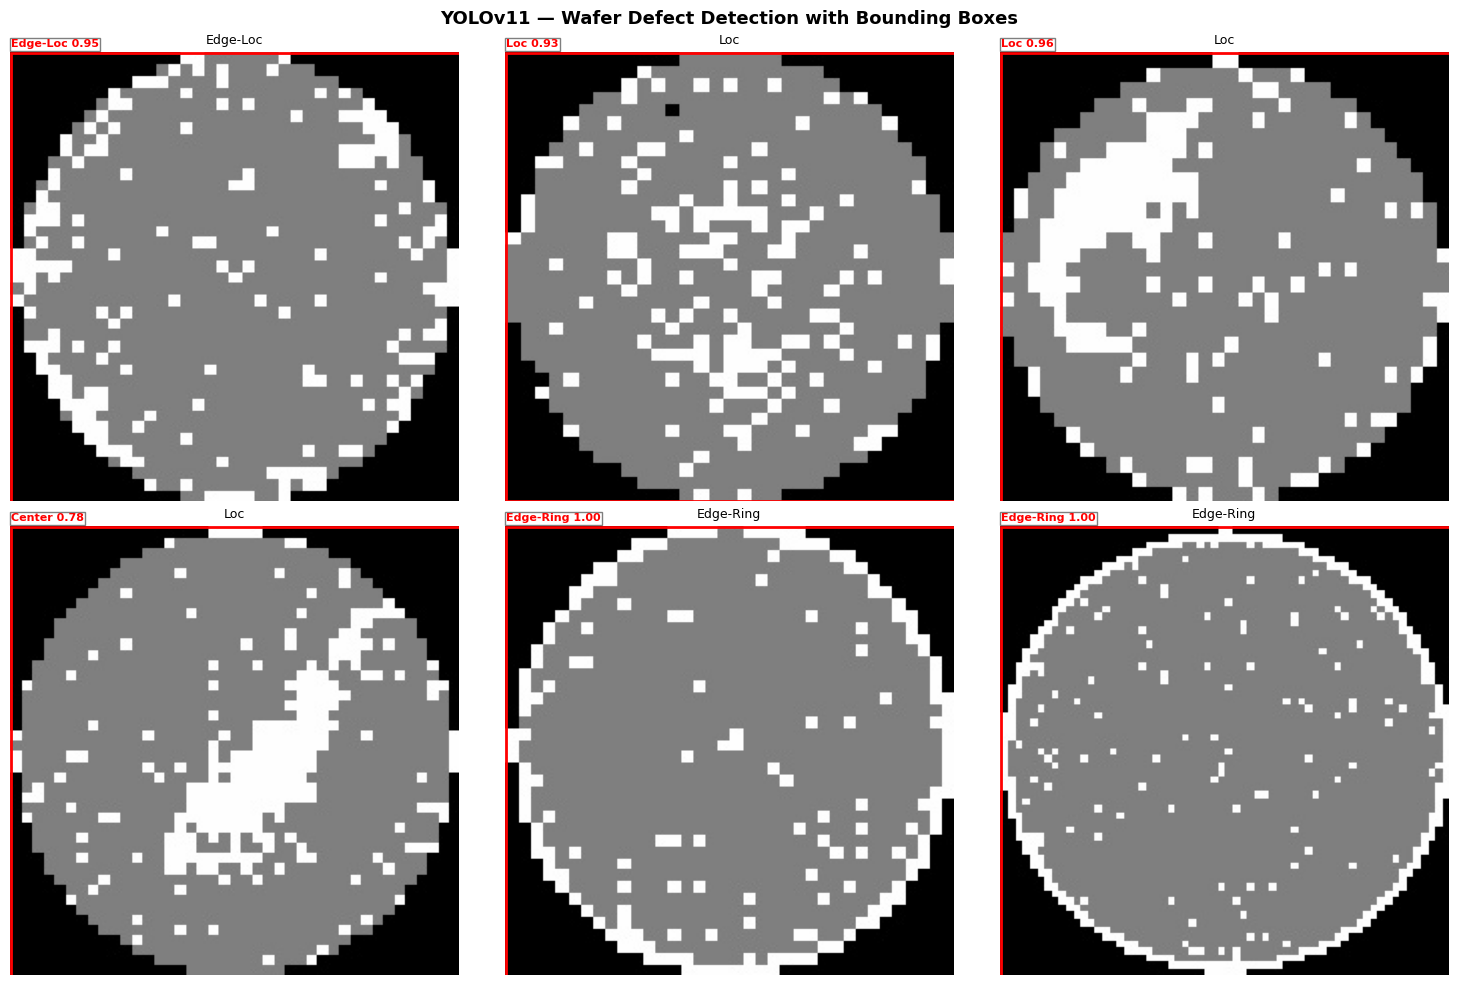

✅ Saved: yolo_detections_grid.png
✅ best_yolo freed from VRAM
RAM  : 8.9 GB used / 13.6 GB total  (70.8% used)
VRAM : 0.21 GB used / 15.6 GB total


In [36]:
# ── Predict on sample images — visualize bounding boxes ──────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def predict_yolo_single(img_path, conf_threshold=0.25):
    """
    Run YOLOv11 on a single wafer image.
    Draws bounding boxes with class names and confidence scores.
    """
    results = best_yolo.predict(
        source    = img_path,
        conf      = conf_threshold,
        imgsz     = YOLO_IMG_SIZE,
        device    = 0,
        save      = False,
        verbose   = False
    )
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img_rgb, cmap='plasma')

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            cls_id  = int(box.cls[0])
            conf    = float(box.conf[0])
            label   = f'{YOLO_CLASSES[cls_id]} {conf:.2f}'
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-4, label, color='red',
                    fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='white', alpha=0.6, pad=1))

    fname = Path(img_path).stem
    ax.set_title(f'YOLOv11 Detection: {fname}', fontsize=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'yolo_pred_{fname}.png', dpi=120)
    plt.show()

# Run on 6 random val images
val_imgs = list(IMG_VAL.glob('*.jpg'))
sample_imgs = np.random.choice(val_imgs, min(6, len(val_imgs)), replace=False)

print(f'Running YOLOv11 inference on {len(sample_imgs)} sample images...')
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, img_path in enumerate(sample_imgs):
    results = best_yolo.predict(
        source=str(img_path), conf=0.25,
        imgsz=YOLO_IMG_SIZE, device=0, verbose=False)
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    axes[idx].imshow(img, cmap='plasma')
    for r in results:
        for box in r.boxes:
            x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
            cls_id = int(box.cls[0])
            conf   = float(box.conf[0])
            rect = patches.Rectangle((x1,y1),x2-x1,y2-y1,
                                      linewidth=2,edgecolor='red',facecolor='none')
            axes[idx].add_patch(rect)
            axes[idx].text(x1,y1-3,f'{YOLO_CLASSES[cls_id]} {conf:.2f}',
                           color='red',fontsize=8,fontweight='bold',
                           bbox=dict(facecolor='white',alpha=0.5,pad=1))
    axes[idx].set_title(Path(img_path).stem.split('_')[0], fontsize=9)
    axes[idx].axis('off')

plt.suptitle('YOLOv11 — Wafer Defect Detection with Bounding Boxes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('yolo_detections_grid.png', dpi=130)
plt.show()
print('✅ Saved: yolo_detections_grid.png')

# ── Free YOLO after inference is done ────────────────────────────────────────
del best_yolo
gc.collect(); torch.cuda.empty_cache()
print('✅ best_yolo freed from VRAM')
print_memory()


In [37]:
print('=' * 55)
print('COMPLETE MODEL COMPARISON — ALL 9 CLASSES')
print('=' * 55)
row = '{:<25} {:<20} {}'
print(row.format('Model', 'Task', 'Key Metric'))
print('-' * 55)
print(row.format('CNN Baseline',           'Classification',     f'Accuracy: {accuracy_score(cnn_labels, cnn_preds):.4f}'))
print(row.format('Hybrid CNN-Transformer', 'Classification',     f'Accuracy: {accuracy_score(hybrid_labels, hybrid_preds):.4f}'))
print(row.format('Vision Transformer',     'Classification',     f'Accuracy: {accuracy_score(vit_labels, vit_preds):.4f}'))
print(row.format('YOLOv11s',               'Detection+Location', f'mAP@0.5 : {metrics.box.map50:.4f}'))
print('=' * 55)
print()
print('KEY DIFFERENCE:')
print('  CNN / ViT / Hybrid  → tells you WHAT defect (9 classes)')
print('  YOLOv11             → tells you WHAT + WHERE (bounding box)')


COMPLETE MODEL COMPARISON — ALL 9 CLASSES
Model                     Task                 Key Metric
-------------------------------------------------------
CNN Baseline              Classification       Accuracy: 0.7719
Hybrid CNN-Transformer    Classification       Accuracy: 0.8477
Vision Transformer        Classification       Accuracy: 0.7677
YOLOv11s                  Detection+Location   mAP@0.5 : 0.9777

KEY DIFFERENCE:
  CNN / ViT / Hybrid  → tells you WHAT defect (9 classes)
  YOLOv11             → tells you WHAT + WHERE (bounding box)


## 🚨 STEP 15 — EfficientAD: Unsupervised Anomaly Detection

In [38]:
# ── Reload models that were freed before YOLO ────────────────────────────────
cnn_model    = WaferCNN(NUM_CLASSES).to(DEVICE)
hybrid_model = HybridCNNTransformer(NUM_CLASSES).to(DEVICE)

class WaferAutoencoder(nn.Module):
    """Trains ONLY on normal wafers. High reconstruction error = unknown defect."""
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 8,  3, padding=1), nn.ReLU())
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16, 32, 2, stride=2), nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1), nn.Sigmoid())
    def forward(self, x): return self.decoder(self.encoder(x))

ae_model = WaferAutoencoder().to(DEVICE)

# ── Normal-only loader using DiskDataset (no X_normal array in RAM) ───────────
none_label     = le.transform(['none'])[0]
normal_mask    = y_train == none_label
normal_indices = idx_train[normal_mask]
normal_labels  = y_train[normal_mask]

normal_loader = DataLoader(
    DiskDataset(normal_indices, normal_labels, SAVE_DIR),
    batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

print(f'Normal (none) training samples: {len(normal_indices):,}')
print_memory()


Normal (none) training samples: 2,100
RAM  : 8.9 GB used / 13.6 GB total  (70.4% used)
VRAM : 0.21 GB used / 15.6 GB total


In [39]:
ae_optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
ae_criterion = nn.MSELoss()

ae_losses = []
AE_EPOCHS = 20

print('Training Autoencoder on normal wafers...')
for epoch in range(1, AE_EPOCHS + 1):
    ae_model.train()
    total_loss = 0
    for imgs, _ in normal_loader:
        imgs = imgs.to(DEVICE)
        recon = ae_model(imgs)
        loss = ae_criterion(recon, imgs)
        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    avg = total_loss / len(normal_indices)
    ae_losses.append(avg)
    if epoch % 5 == 0:
        print(f'  Epoch {epoch}/{AE_EPOCHS}  Recon Loss: {avg:.6f}')

torch.save(ae_model.state_dict(), 'best_autoencoder.pth')
print('✅ Autoencoder trained.')

Training Autoencoder on normal wafers...
  Epoch 5/20  Recon Loss: 0.024990
  Epoch 10/20  Recon Loss: 0.017278
  Epoch 15/20  Recon Loss: 0.012577
  Epoch 20/20  Recon Loss: 0.010238
✅ Autoencoder trained.


Anomaly Threshold : 0.014070
Anomalies Detected: 2847 / 4050
Anomaly Rate      : 70.30%


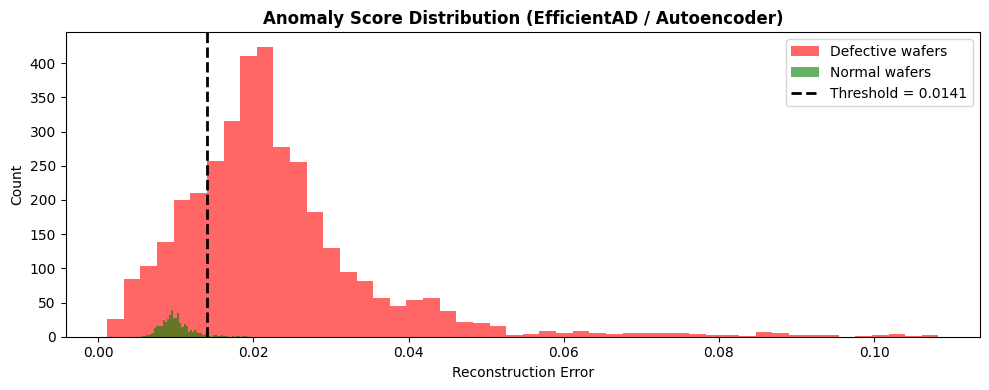

In [40]:
# ── Compute anomaly scores on test set ───────────────────────────────────────
ae_model.eval()
anomaly_scores = []

with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(DEVICE)
        recon = ae_model(imgs)
        pixel_mse = ((recon - imgs) ** 2).mean(dim=(1, 2, 3))
        anomaly_scores.extend(pixel_mse.cpu().numpy())

anomaly_scores = np.array(anomaly_scores)

# Threshold: mean + 2*std on normal validation images
normal_val_mask = y_test == none_label
normal_scores = anomaly_scores[normal_val_mask]
threshold = normal_scores.mean() + 2 * normal_scores.std()
is_anomaly = anomaly_scores > threshold

print(f'Anomaly Threshold : {threshold:.6f}')
print(f'Anomalies Detected: {is_anomaly.sum()} / {len(is_anomaly)}')
print(f'Anomaly Rate      : {is_anomaly.mean()*100:.2f}%')

# Visualise anomaly score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(anomaly_scores[~normal_val_mask], bins=50, alpha=0.6,
        label='Defective wafers', color='red')
ax.hist(anomaly_scores[ normal_val_mask], bins=50, alpha=0.6,
        label='Normal wafers',   color='green')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold = {threshold:.4f}')
ax.set_title('Anomaly Score Distribution (EfficientAD / Autoencoder)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Reconstruction Error'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('anomaly_distribution.png', dpi=150)
plt.show()

## 🎯 STEP 16 — Single Image Prediction (Inference Demo)

True label: none


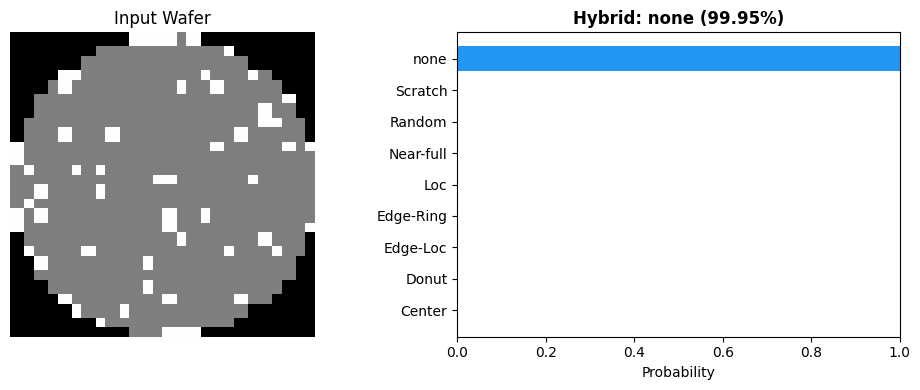

Predicted : none (99.95%)


In [41]:
def predict_single(model, disk_idx, class_names, model_name='Model'):
    """Predict defect class for a single wafer from disk."""
    model.eval()
    img    = np.load(f'{SAVE_DIR}/{disk_idx:06d}.npy')
    tensor = torch.tensor(img).permute(2,0,1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_cls   = class_names[np.argmax(probs)]
    confidence = probs.max()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img, cmap='plasma')
    ax1.set_title('Input Wafer'); ax1.axis('off')
    ax2.barh(class_names, probs, color='#2196F3')
    ax2.set_xlim(0, 1)
    ax2.set_title(f'{model_name}: {pred_cls} ({confidence:.2%})', fontweight='bold')
    ax2.set_xlabel('Probability')
    plt.tight_layout()
    plt.savefig(f'pred_{model_name}.png', dpi=150); plt.show()
    return pred_cls, confidence

# Reload hybrid weights (may have been freed before YOLO)
hybrid_model.load_state_dict(torch.load('best_hybrid.pth', map_location=DEVICE))

# Demo on a random test sample
sample_disk_idx = idx_test[10]
true_label      = CLASS_NAMES[y_test[10]]
print(f'True label: {true_label}')
pred_cls, conf  = predict_single(hybrid_model, sample_disk_idx, CLASS_NAMES, 'Hybrid')
print(f'Predicted : {pred_cls} ({conf:.2%})')


## 🌐 STEP 17 — Streamlit Deployment App

In [42]:
# ── Run this cell to write app.py ────────────────────────────────────────────
# Also saves CLASS_NAMES to disk so app.py always uses the correct list
import numpy as np

# Save class names used during training → app.py reads this dynamically
np.save('wafer_imgs/class_names.npy', np.array(CLASS_NAMES))
print(f'✅ Saved CLASS_NAMES: {CLASS_NAMES}')
print(f'   NUM_CLASSES = {len(CLASS_NAMES)}')

streamlit_code = '''
import streamlit as st
import numpy as np
import cv2
import torch
import torch.nn as nn
from PIL import Image
import os

st.set_page_config(
    page_title="Silicon Wafer Defect Detection",
    page_icon="\\U0001f52c",
    layout="centered"
)

# ── Load class names saved during training (always correct count) ─────────────
CLASS_NAMES = list(np.load("wafer_imgs/class_names.npy", allow_pickle=True))
NUM_CLASSES = len(CLASS_NAMES)  # reads actual value: {len(CLASS_NAMES)}
IMG_SIZE    = 64
DEVICE      = torch.device("cpu")

# ── Model architecture — must exactly match training ──────────────────────────
class HybridCNNTransformer(nn.Module):
    def __init__(self, num_classes, img_size=64, d_model=128,
                 nhead=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, d_model, 3, padding=1), nn.BatchNorm2d(d_model), nn.ReLU(),
        )
        feat_h   = img_size // 4
        seq_len  = feat_h * feat_h
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)   # num_classes comes from saved file
        )

    def forward(self, x):
        feat = self.cnn_backbone(x)
        B, C, H, W = feat.shape
        feat = feat.flatten(2).transpose(1, 2)
        feat = feat + self.pos_embed[:, :feat.size(1), :]
        feat = self.transformer(feat)
        return self.head(feat.mean(dim=1))

@st.cache_resource
def load_model():
    # Reads NUM_CLASSES from file — always matches the trained weights
    model = HybridCNNTransformer(num_classes=NUM_CLASSES).to(DEVICE)
    model.load_state_dict(torch.load("best_hybrid.pth", map_location=DEVICE))
    model.eval()
    return model

def preprocess(img_pil, size=IMG_SIZE):
    # Match wafer_to_img() exactly: grayscale → resize → 3-channel stack
    img_gray = np.array(img_pil.convert("L"), dtype=np.float32)
    img_gray = cv2.resize(img_gray, (size, size), interpolation=cv2.INTER_NEAREST)
    img_gray = img_gray / 255.0
    return np.stack([img_gray]*3, axis=-1)   # (H, W, 3)

# ── UI ────────────────────────────────────────────────────────────────────────
st.title("\\U0001f52c Silicon Wafer Defect Detection")
st.caption(f"Model trained on WM811K | {NUM_CLASSES} defect classes | Hybrid CNN-Transformer")

col1, col2 = st.columns(2)
with col1:
    uploaded_file = st.file_uploader(
        "Upload Wafer Image (PNG / JPG)", type=["png", "jpg", "jpeg"])

if uploaded_file:
    img_pil = Image.open(uploaded_file)
    img_arr = preprocess(img_pil)

    with col1:
        st.image(img_pil, caption="Uploaded Wafer", width=280)

    model  = load_model()
    tensor = torch.tensor(img_arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]

    pred_idx   = int(np.argmax(probs))
    pred_cls   = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])

    with col2:
        st.metric("Predicted Defect", pred_cls)
        st.metric("Confidence", f"{confidence:.2%}")
        st.subheader("All Class Probabilities")
        for cls, p in sorted(zip(CLASS_NAMES, probs.tolist()), key=lambda x: -x[1]):
            st.progress(float(p), text=f"{cls}: {p:.2%}")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print('\n✅ app.py written with correct num_classes =', len(CLASS_NAMES))
print('   CLASS_NAMES:', CLASS_NAMES)


✅ Saved CLASS_NAMES: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']
   NUM_CLASSES = 9

✅ app.py written with correct num_classes = 9
   CLASS_NAMES: ['Center', 'Donut', 'Edge-Loc', 'Edge-Ring', 'Loc', 'Near-full', 'Random', 'Scratch', 'none']


## 🚀 STEP 18 — Run Streamlit in Colab (with Tunnel)

In [43]:
# ═══════════════════════════════════════════════════════════════════════════
# STREAMLIT LAUNCHER — Fixed for Google Colab T4
# Problem 1: streamlit not found → install it fresh in this cell
# Problem 2: localtunnel is slow → use colab_kernel_launcher instead
# ═══════════════════════════════════════════════════════════════════════════

import subprocess, sys, time, threading, os

# ── Step 1: Install streamlit (fast, ~10 seconds) ────────────────────────────
print('Installing streamlit...')
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'streamlit'], check=True)
print('✅ Streamlit installed')

# ── Step 2: Verify app.py exists ─────────────────────────────────────────────
assert os.path.exists('app.py'), '❌ app.py not found — run the streamlit-code cell first!'
print('✅ app.py found')

# ── Step 3: Start streamlit as background process ────────────────────────────
def run():
    subprocess.Popen(
        [sys.executable, '-m', 'streamlit', 'run', 'app.py',
         '--server.port', '8501',
         '--server.headless', 'true',
         '--server.enableCORS', 'false',
         '--server.enableXsrfProtection', 'false'],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )

threading.Thread(target=run, daemon=True).start()
print('⏳ Waiting for Streamlit to start...')
time.sleep(6)

# ── Step 4: Expose via colab_kernel_launcher (built-in, instant URL) ─────────
from google.colab.output import eval_js
print('\n✅ Streamlit is running!')
print('🔗 Opening public URL...')
print(eval_js("google.colab.kernel.proxyPort(8501)"))


Installing streamlit...
✅ Streamlit installed
✅ app.py found
⏳ Waiting for Streamlit to start...

✅ Streamlit is running!
🔗 Opening public URL...
https://8501-gpu-t4-s-kkb-euw4c2-1g4g66tmjys0a-c.europe-west4-2.prod.colab.dev


## 🎤 STEP 19 — Viva Q&A Reference Sheet

| Question | Answer |
|----------|--------|
| Why remove 'none' class? | Prevents model from always predicting majority class (85% none = biased model) |
| Why Albumentations for balancing? | Generates realistic variations (flip, rotate, elastic), prevents overfitting, improves generalization |
| Why ViT over CNN? | ViT captures long-range global dependencies via self-attention; CNN only sees local features via kernels |
| What is Hybrid CNN-Transformer? | CNN extracts local textures → flattened as sequence → Transformer captures spatial dependencies across the whole image |
| What is EfficientAD / Autoencoder? | Trained only on normal wafers; high reconstruction error at test time → unseen/unknown defect detected |
| Why mAP instead of accuracy? | Accuracy is misleading for imbalanced datasets; mAP measures precision across all recall levels per class |
| What is a waferMap? | 2D grid of die positions, each die labeled 0 (absent), 1 (normal), or 2 (defective) |
| Why BatchNorm? | Normalizes layer activations → faster convergence, less sensitive to learning rate |
| What is Cosine Annealing? | LR scheduler that smoothly decays learning rate to avoid local minima near training end |
| Why AdamW over Adam? | AdamW correctly decouples weight decay from gradient update, better regularization |


---
## 📦 Saved Files Summary

| File | Description |
|------|-------------|
| `best_cnn.pth` | Best CNN weights |
| `best_hybrid.pth` | Best Hybrid CNN-Transformer weights |
| `best_vit.pth` | Best Vision Transformer weights |
| `best_autoencoder.pth` | Anomaly detection autoencoder |
| `app.py` | Streamlit web application |
| `class_distribution.png` | EDA plot |
| `sample_wafers.png` | Sample wafer images |
| `training_curves.png` | Training history plots |
| `confusion_matrix_*.png` | Per-model confusion matrices |
| `model_comparison.png` | Side-by-side accuracy/F1 chart |
| `anomaly_distribution.png` | Anomaly score histogram |

---
*Project by B. Reshmitha (23B81A67G5) & K. Ushaswi (23B81A67J6) — CVR College of Engineering, Dept. of CSE (Data Science)*